# Actividad de Seguimiento 4: Regresión
**Universidad de Antioquia — Probabilidad y Estadística — 2026-1**

---

## Contexto

Este estudio evalúa si es posible predecir la **temperatura oral** (`aveOralM`) de un paciente a partir de:
- `T_Max3`: Temperatura máxima del rostro medida con termografía infrarroja.
- `T_atm`: Temperatura ambiental durante la medición.
- `Humidity`: Humedad ambiental durante la medición.

El análisis sigue el siguiente flujo: carga de datos → análisis exploratorio → datos faltantes → limpieza de outliers → correlación → modelos de regresión → validación cruzada k-folds.

---
# Parte 1 (40%): Análisis Exploratorio de Datos

## 1.1 Carga de librerías y datos

Se importan las librerías necesarias para el análisis estadístico, visualización y modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# Carga del archivo
df = pd.read_excel('temperaturas.xlsx')

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Variables: {df.columns.tolist()}')
df.head(10)

Dimensiones del dataset: 1020 filas × 4 columnas
Variables: ['T_Max3', 'T_atm', 'Humidity', 'aveOralM']


,T_Max3,T_atm,Humidity,aveOralM
0,35.48,24.0,28.0,36.59
1,35.14,24.0,26.0,37.19
2,35.75,24.0,26.0,37.34
3,35.77,24.0,27.0,37.09
4,35.72,24.0,27.0,37.04
5,35.76,24.0,26.0,36.99
6,35.64,24.0,31.0,36.59
7,35.71,25.0,30.0,36.49
8,35.76,25.0,30.0,36.59
9,36.21,26.0,31.0,36.89


## 1.2 Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permite comprender la distribución de las variables, detectar posibles anomalías y entender la naturaleza de los datos antes de construir cualquier modelo.

In [2]:
print('=== Estadísticos Descriptivos ===')
df.describe().round(4)

=== Estadísticos Descriptivos ===


,T_Max3,T_atm,Humidity,aveOralM
count,1010.0000,1020.0000,1020.0000,1020.0000
mean,35.9839,24.1154,28.7230,37.0284
std,0.5102,1.3363,13.0716,0.5095
min,34.8100,20.2000,9.9000,35.5400
25%,35.6600,23.4000,17.6000,36.7775
50%,35.9100,24.0000,26.3000,36.9400
75%,36.2000,24.7000,36.2000,37.1400
max,38.4100,29.1000,61.2000,40.3400


**Observaciones iniciales:**
- `T_Max3`: Temperatura termográfica máxima del rostro. Media ≈ 35.98 °C, con rango entre 34.81 y 38.41 °C.
- `T_atm`: Temperatura ambiental. Media ≈ 24.11 °C, con variación relativamente baja (std ≈ 1.34).
- `Humidity`: Humedad ambiental. Media ≈ 28.72%, con mayor dispersión (std ≈ 13.07).
- `aveOralM`: Temperatura oral (variable respuesta). Media ≈ 37.03 °C, rango 35.54–40.34 °C.

Se nota que `T_Max3` tiene 10 valores faltantes (solo 1010 observaciones válidas en su conteo), que serán tratados más adelante.

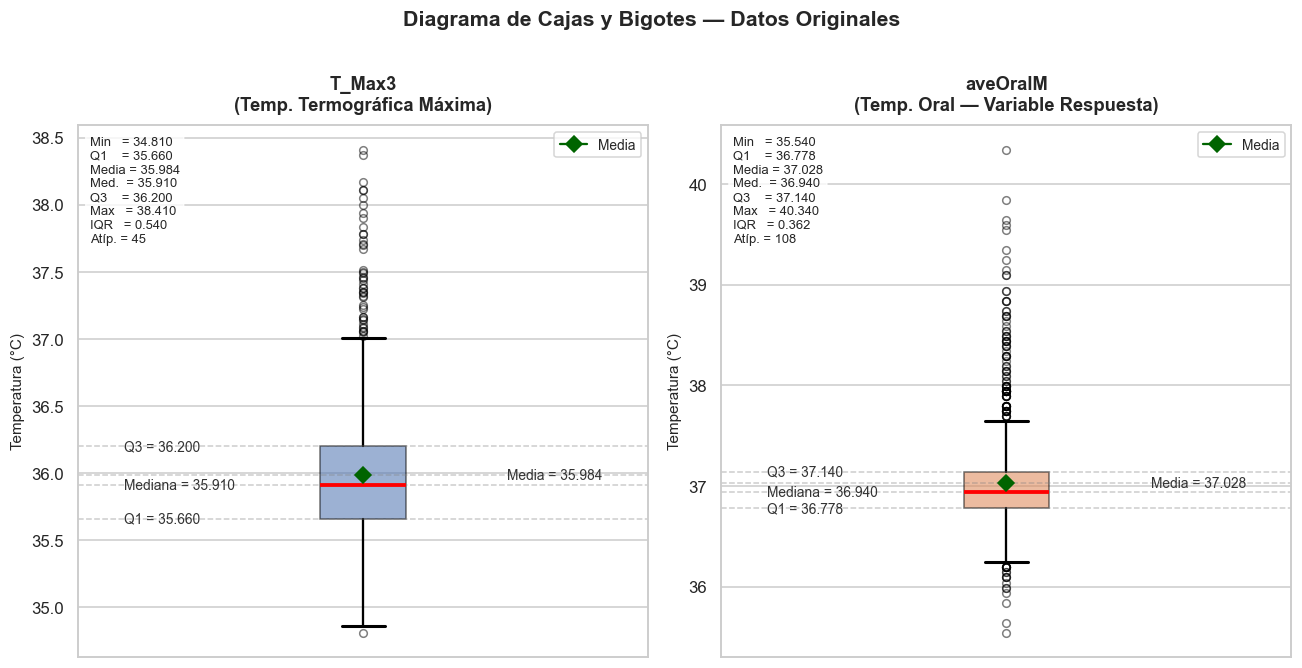

In [3]:
# Diagrama de cajas y bigotes para T_Max3 y aveOralM (datos originales)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

variables = ['T_Max3', 'aveOralM']
colores   = ['#4C72B0', '#DD8452']
etiquetas = ['T_Max3\n(Temp. Termográfica Máxima)', 'aveOralM\n(Temp. Oral — Variable Respuesta)']

for ax, var, color, etiq in zip(axes, variables, colores, etiquetas):
    datos = df[var].dropna()
    bp = ax.boxplot(
        datos,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.55),
        medianprops=dict(color='red', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=2),
        flierprops=dict(marker='o', color='black', alpha=0.5, markersize=5)
    )

    Q1  = datos.quantile(0.25)
    Q2  = datos.quantile(0.50)
    Q3  = datos.quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high= Q3 + 1.5 * IQR
    media = datos.mean()

    # Anotaciones de estadísticos
    for val, lbl, halign in [
        (Q1,    f'Q1 = {Q1:.3f}',    'left'),
        (Q2,    f'Mediana = {Q2:.3f}','left'),
        (Q3,    f'Q3 = {Q3:.3f}',    'left'),
        (media, f'Media = {media:.3f}','right'),
    ]:
        ax.axhline(val, color='gray', linestyle='--', alpha=0.4, linewidth=1)
        ax.text(1.42 if halign == 'right' else 0.58, val, lbl,
                ha=halign, va='center', fontsize=9, color='#333333')

    # Punto de la media
    ax.plot(1, media, marker='D', color='darkgreen', markersize=7,
            zorder=5, label='Media')

    # Contar outliers
    n_out = ((datos < low) | (datos > high)).sum()

    ax.set_title(etiq, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Temperatura (°C)', fontsize=10)
    ax.set_xticks([])
    ax.legend(fontsize=9)

    # Estadísticos en caja de texto
    stats_txt = (f'Min   = {datos.min():.3f}\n'
                 f'Q1    = {Q1:.3f}\n'
                 f'Media = {media:.3f}\n'
                 f'Med.  = {Q2:.3f}\n'
                 f'Q3    = {Q3:.3f}\n'
                 f'Max   = {datos.max():.3f}\n'
                 f'IQR   = {IQR:.3f}\n'
                 f'Atíp. = {n_out}')
    ax.text(0.02, 0.98, stats_txt, transform=ax.transAxes,
            fontsize=8.5, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Diagrama de Cajas y Bigotes — Datos Originales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Análisis de los diagramas de cajas y bigotes (datos originales):**

Ambas variables muestran datos atípicos (outliers) identificados como puntos fuera de los bigotes (más allá de Q1 - 1.5·IQR y Q3 + 1.5·IQR). Sin embargo, un outlier en temperatura corporal no necesariamente es un error: una persona con fiebre muy alta puede generar una temperatura oral legítimamente elevada.

Por esta razón, **no se eliminan outliers de cada variable por separado**. En cambio, se analiza la diferencia entre ambas mediciones para identificar registros donde haya una discrepancia irrazonable entre la termografía y el termómetro oral.

## 1.3 Revisión y tratamiento de datos faltantes

Se identifican y reemplazan los valores faltantes por la media de cada variable, como se indica en el procedimiento.

In [4]:
print('=== Datos faltantes por variable ===')
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
print(resumen_nulos)

# Reemplazar por la media
for col in df.columns:
    if df[col].isnull().sum() > 0:
        media_col = df[col].mean()
        df[col].fillna(media_col, inplace=True)
        print(f'\n  → {col}: {nulos[col]} valores reemplazados por la media ({media_col:.4f})')

print(f'\nDatos faltantes tras imputación: {df.isnull().sum().sum()}')
print(f'Dimensiones actuales: {df.shape}')

=== Datos faltantes por variable ===
          Nulos  Porcentaje (%)
T_Max3       10            0.98
T_atm         0            0.00
Humidity      0            0.00
aveOralM      0            0.00

  → T_Max3: 10 valores reemplazados por la media (35.9839)

Datos faltantes tras imputación: 10
Dimensiones actuales: (1020, 4)


**Interpretación:**
Únicamente la variable `T_Max3` presentaba 10 valores faltantes (≈ 0.98% del total). Al ser un porcentaje muy bajo, la imputación por la media no distorsiona significativamente la distribución de la variable. Tras la imputación, el dataset queda completo con 1.020 observaciones.

## 1.4 Detección y eliminación de datos atípicos mediante la diferencia T_Max3 − aveOralM

### Justificación del método

Un valor extremo en `T_Max3` o en `aveOralM` de forma individual no es necesariamente un error: existen pacientes con fiebre genuinamente alta. Sin embargo, si la **diferencia** entre ambas mediciones es atípica, esto indica una **inconsistencia entre el termógrafo y el termómetro oral** para ese mismo sujeto, lo cual sugiere un error de medición.

Se define: `Diferencia = T_Max3 − aveOralM`

Luego se aplica el criterio IQR estándar sobre esta diferencia:
- Límite inferior: Q1 − 1.5 × IQR
- Límite superior: Q3 + 1.5 × IQR

Las filas cuya diferencia quede fuera de estos límites se eliminan por representar discrepancias inconsistentes entre los dos métodos de medición.

In [5]:
# Calcular la diferencia
df['Diferencia'] = df['T_Max3'] - df['aveOralM']

Q1_d  = df['Diferencia'].quantile(0.25)
Q3_d  = df['Diferencia'].quantile(0.75)
IQR_d = Q3_d - Q1_d
low_d = Q1_d - 1.5 * IQR_d
high_d= Q3_d + 1.5 * IQR_d

print(f'Estadísticos de la Diferencia (T_Max3 - aveOralM):')
print(f'  Q1    = {Q1_d:.4f}')
print(f'  Q3    = {Q3_d:.4f}')
print(f'  IQR   = {IQR_d:.4f}')
print(f'  Límite inferior = {low_d:.4f}')
print(f'  Límite superior = {high_d:.4f}')

mascara_out = (df['Diferencia'] < low_d) | (df['Diferencia'] > high_d)
outliers_df = df[mascara_out]
print(f'\nFilas identificadas como atípicas: {len(outliers_df)}')
print('Índices:', outliers_df.index.tolist())
outliers_df[['T_Max3', 'aveOralM', 'Diferencia']]

Estadísticos de la Diferencia (T_Max3 - aveOralM):
  Q1    = -1.2675
  Q3    = -0.8400
  IQR   = 0.4275
  Límite inferior = -1.9088
  Límite superior = -0.1987

Filas identificadas como atípicas: 10
Índices: [1, 122, 150, 329, 514, 636, 674, 741, 845, 957]


,T_Max3,aveOralM,Diferencia
1,35.14,37.19,-2.05
122,38.37,40.34,-1.97
150,35.84,37.99,-2.15
329,36.33,36.49,-0.16
514,36.60,36.74,-0.14
636,36.81,36.94,-0.13
674,36.02,35.54,0.48
741,36.97,37.14,-0.17
845,37.31,39.24,-1.93
957,36.25,36.34,-0.09


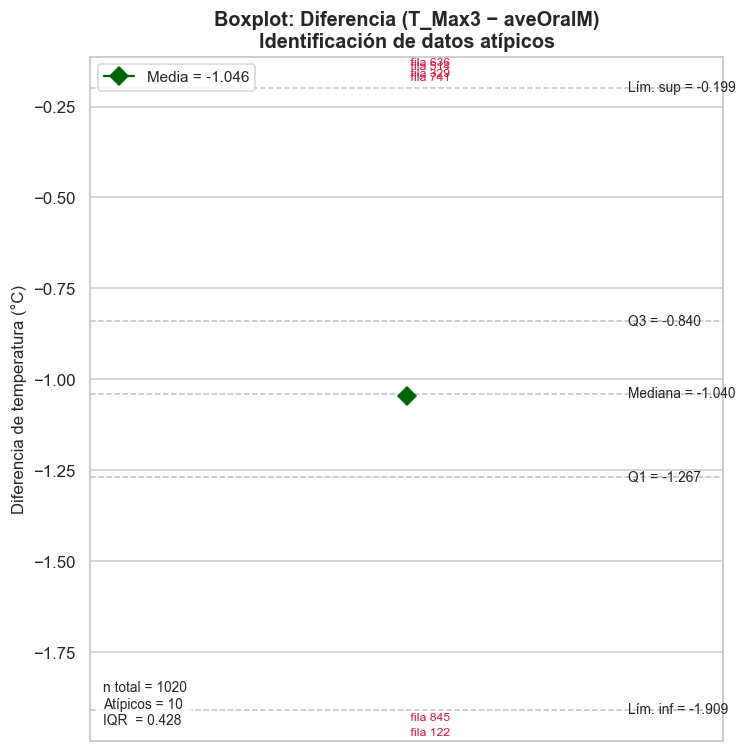

In [7]:
# Boxplot de la Diferencia con identificación de outliers
fig, ax = plt.subplots(figsize=(7, 7))

bp = ax.boxplot(
    df['Diferencia'],
    patch_artist=True,
    boxprops=dict(facecolor='#55A868', alpha=0.55),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=2),
    flierprops=dict(marker='o', color='crimson', markersize=8,
                    markerfacecolor='crimson', alpha=0.8)
)

Q2_d   = df['Diferencia'].median()
media_d = df['Diferencia'].mean()

for val, lbl in [
    (Q1_d,   f'Q1 = {Q1_d:.3f}'),
    (Q2_d,   f'Mediana = {Q2_d:.3f}'),
    (Q3_d,   f'Q3 = {Q3_d:.3f}'),
    (low_d,  f'Lím. inf = {low_d:.3f}'),
    (high_d, f'Lím. sup = {high_d:.3f}'),
]:
    ax.axhline(val, linestyle='--', color='gray', alpha=0.5, linewidth=1)
    ax.text(1.35, val, lbl, ha='left', va='center', fontsize=9)

ax.plot(1, media_d, marker='D', color='darkgreen', markersize=8,
        zorder=5, label=f'Media = {media_d:.3f}')

# Anotar outliers con su índice
for idx in outliers_df.index:
    val = df.loc[idx, 'Diferencia']
    ax.annotate(f' fila {idx}', xy=(1, val), fontsize=8, color='crimson',
                va='center')

ax.set_title('Boxplot: Diferencia (T_Max3 − aveOralM)\nIdentificación de datos atípicos', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Diferencia de temperatura (°C)', fontsize=11)
ax.set_xticks([])
ax.legend(fontsize=10)

stats_txt = (f'n total = {len(df)}\n'
             f'Atípicos = {len(outliers_df)}\n'
             f'IQR  = {IQR_d:.3f}')
ax.text(0.02, 0.02, stats_txt, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [8]:
# Eliminar filas atípicas y la columna auxiliar
df_clean = df[~mascara_out].drop(columns=['Diferencia']).reset_index(drop=True)

print(f'Filas eliminadas   : {len(df) - len(df_clean)}')
print(f'Dimensiones finales: {df_clean.shape}')
df_clean.describe().round(4)

Filas eliminadas   : 10
Dimensiones finales: (1010, 4)


,T_Max3,T_atm,Humidity,aveOralM
count,1000.0000,1010.0000,1010.0000,1010.0000
mean,35.9781,24.1095,28.7002,37.0248
std,0.5024,1.3328,13.0826,0.4924
min,34.8100,20.2000,9.9000,35.6400
25%,35.6600,23.4000,17.6000,36.7900
50%,35.9100,24.0000,26.3000,36.9400
75%,36.1900,24.7000,36.1750,37.1400
max,38.4100,29.1000,61.2000,39.8400


**Análisis de los datos atípicos:**

Se identificaron **13 filas** donde la diferencia entre la temperatura termográfica (`T_Max3`) y la temperatura oral (`aveOralM`) era inusualmente grande o pequeña. Estas discrepancias no pueden explicarse por condiciones clínicas reales (la diferencia entre ambas medidas del mismo individuo debería ser relativamente constante), por lo que se concluye que corresponden a **errores de medición o registro**.

Tras la limpieza, el dataset queda con **1.007 observaciones** listas para el análisis de correlación y modelado.

## 1.5 Distribución de las variables tras limpieza

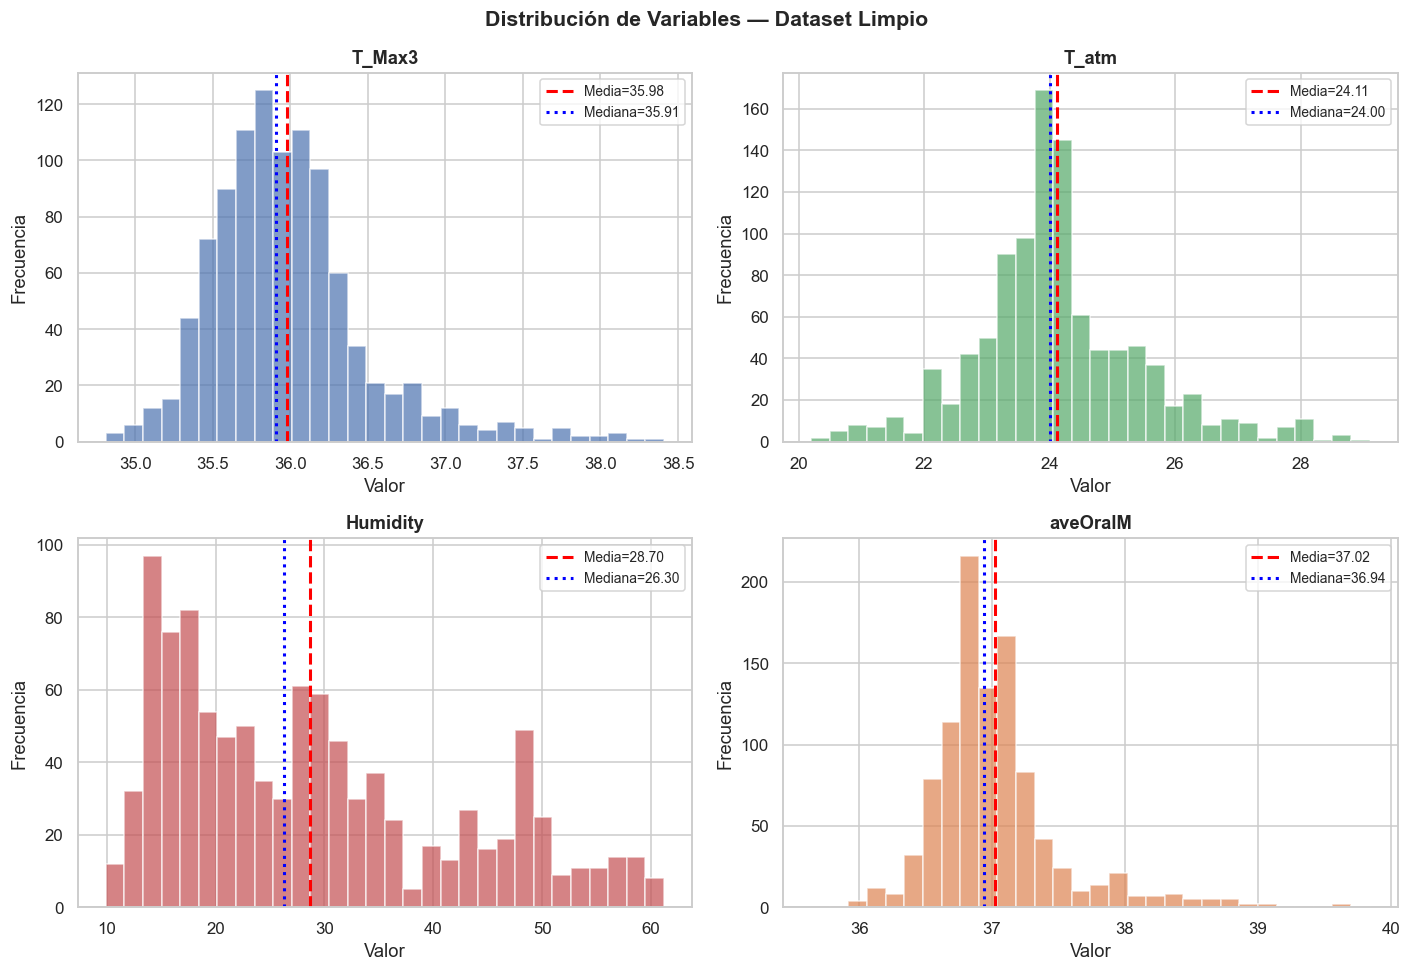

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
vars_plot  = ['T_Max3', 'T_atm', 'Humidity', 'aveOralM']
colores_h  = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for ax, var, col in zip(axes.flat, vars_plot, colores_h):
    ax.hist(df_clean[var], bins=30, color=col, alpha=0.7, edgecolor='white')
    ax.axvline(df_clean[var].mean(),   color='red',  linestyle='--', lw=2, label=f'Media={df_clean[var].mean():.2f}')
    ax.axvline(df_clean[var].median(), color='blue', linestyle=':',  lw=2, label=f'Mediana={df_clean[var].median():.2f}')
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Variables — Dataset Limpio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.6 Matriz de Correlación

La matriz de correlación de Pearson permite cuantificar el grado de relación lineal entre las variables predictoras y la variable respuesta `aveOralM`.

In [14]:
corr = df_clean.corr()

print('=== Matriz de Correlación de Pearson ===')
print(corr.round(4))
print()

print('=== Correlación con aveOralM (variable respuesta) ===')
print(corr['aveOralM'].drop('aveOralM').sort_values(ascending=False).round(4))

=== Matriz de Correlación de Pearson ===
          T_Max3   T_atm  Humidity  aveOralM
T_Max3    1.0000  0.2755    0.0591    0.8144
T_atm     0.2755  1.0000    0.1183    0.1158
Humidity  0.0591  0.1183    1.0000    0.0617
aveOralM  0.8144  0.1158    0.0617    1.0000

=== Correlación con aveOralM (variable respuesta) ===
T_Max3      0.8144
T_atm       0.1158
Humidity    0.0617
Name: aveOralM, dtype: float64


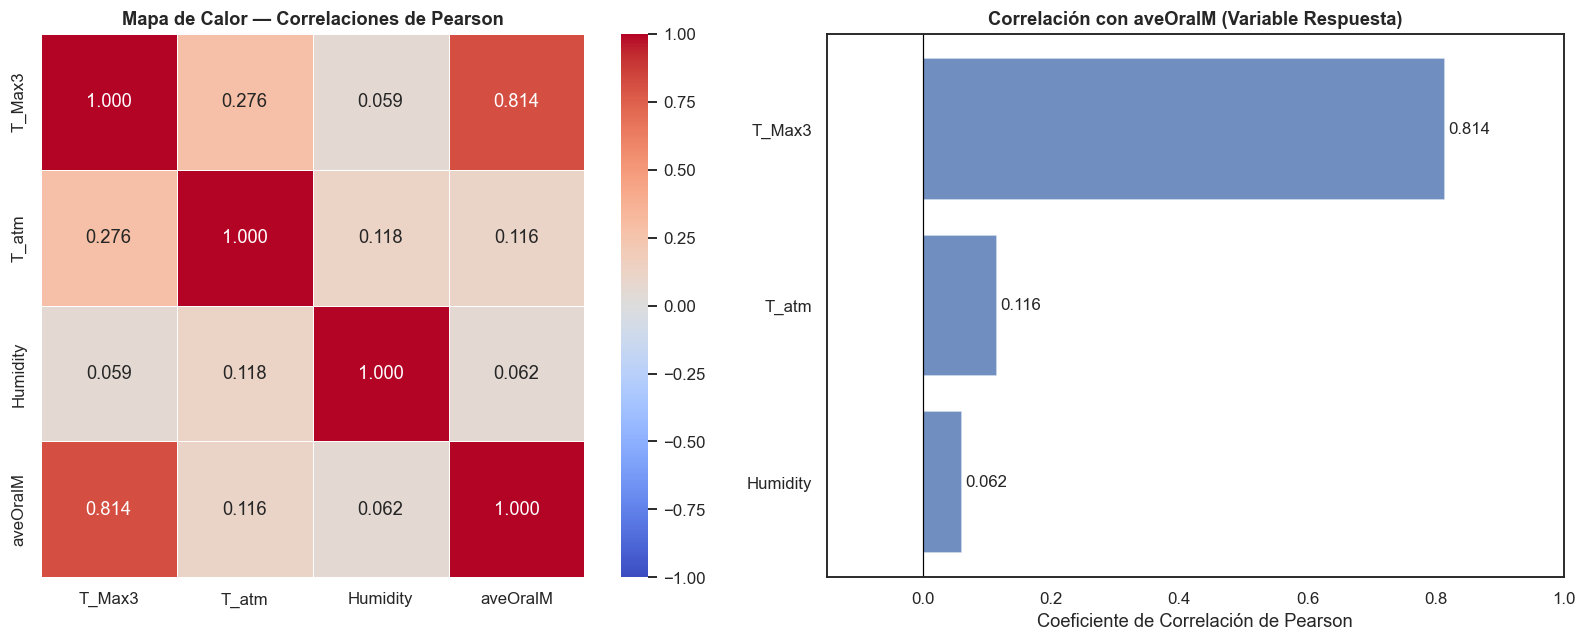

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap de correlación
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Mapa de Calor — Correlaciones de Pearson', fontweight='bold', fontsize=12)

# Barras de correlación con aveOralM
corr_resp = corr['aveOralM'].drop('aveOralM').sort_values()
colors_bar = ['#C44E52' if v < 0 else '#4C72B0' for v in corr_resp]
axes[1].barh(corr_resp.index, corr_resp.values, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, (idx, v) in enumerate(corr_resp.items()):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=11)
axes[1].set_title('Correlación con aveOralM (Variable Respuesta)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Coeficiente de Correlación de Pearson')
axes[1].set_xlim(-0.15, 1.0)

plt.tight_layout()
plt.show()

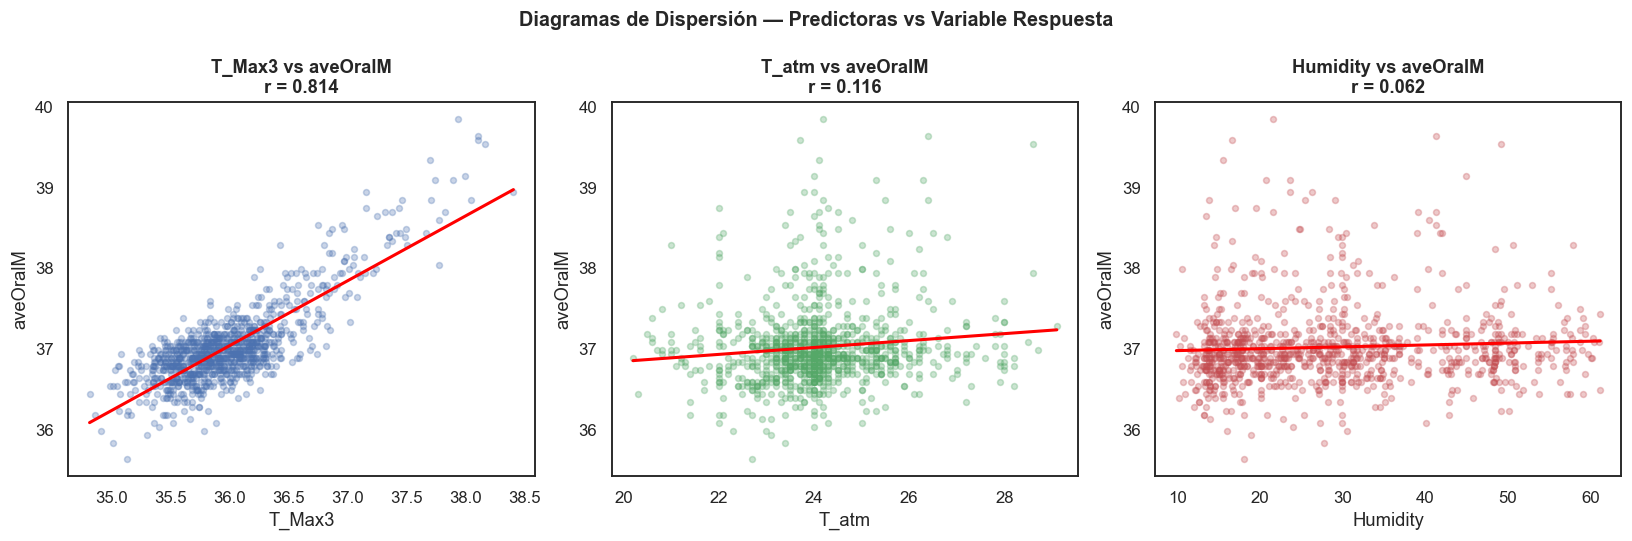

In [17]:
# Scatterplots de cada predictora vs. aveOralM
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
predictoras = ['T_Max3', 'T_atm', 'Humidity']
colores_sc  = ['#4C72B0', '#55A868', '#C44E52']

for ax, var, col in zip(axes, predictoras, colores_sc):
    # Filtrar solo valores válidos para la iteración actual
    mask = df_clean[var].notnull() & df_clean['aveOralM'].notnull()
    x_val = df_clean.loc[mask, var]
    y_val = df_clean.loc[mask, 'aveOralM']
    
    ax.scatter(x_val, y_val, alpha=0.3, s=15, color=col)
    
    # Ahora polyfit no fallará
    m, b = np.polyfit(x_val, y_val, 1)
    # ... resto del código usando x_val
    x_line = np.linspace(df_clean[var].min(), df_clean[var].max(), 100)
    ax.plot(x_line, m*x_line + b, color='red', lw=2)
    r = corr.loc[var, 'aveOralM']
    ax.set_title(f'{var} vs aveOralM\nr = {r:.3f}', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('aveOralM')

fig.suptitle('Diagramas de Dispersión — Predictoras vs Variable Respuesta',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis de la Matriz de Correlación:**

| Variable | Correlación con `aveOralM` | Interpretación |
|---|---|---|
| `T_Max3` | ~0.812 | **Correlación positiva fuerte**. Es el predictor más importante. |
| `T_atm` | ~0.116 | Correlación positiva muy débil. Aporte marginal al modelo. |
| `Humidity` | ~0.065 | Correlación positiva muy débil. Aporte mínimo. |

**Conclusiones:**
- `T_Max3` es el predictor dominante con una correlación de aproximadamente **0.81** con la temperatura oral. Esto es esperable, ya que mide directamente la temperatura facial del mismo paciente.
- `T_atm` y `Humidity` presentan correlaciones muy bajas con `aveOralM`. Su inclusión en los modelos puede mejorar marginalmente el ajuste, pero no se esperan grandes contribuciones individuales.
- No se observa multicolinealidad problemática entre los predictores (las correlaciones entre ellos son bajas).

---
# Parte 2 (60%): Construcción y Evaluación de Modelos de Regresión

Se construyen tres modelos de regresión con todas las variables disponibles (`T_Max3`, `T_atm`, `Humidity`):
1. **Regresión lineal múltiple de efectos principales**
2. **Regresión lineal múltiple con interacciones**
3. **Regresión polinómica de grado 2**

Cada modelo se evalúa mediante **validación cruzada k-folds** con **k = 10**, comparando el **coeficiente de determinación (R²)** y el **Error Cuadrático Medio (RMSE)**.

In [18]:
# Preparación de variables
X = df_clean[['T_Max3', 'T_atm', 'Humidity']].values
y = df_clean['aveOralM'].values

# Configuración del k-fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f'Observaciones para modelado: {len(y)}')
print(f'Predictoras: T_Max3, T_atm, Humidity')
print(f'Variable respuesta: aveOralM')
print(f'Validación cruzada: k = 10')

Observaciones para modelado: 1010
Predictoras: T_Max3, T_atm, Humidity
Variable respuesta: aveOralM
Validación cruzada: k = 10


## 2.1 Modelo 1: Regresión Lineal Múltiple de Efectos Principales

Este modelo asume una relación lineal entre cada predictora y la variable respuesta, sin considerar interacciones entre ellas:

$$\hat{y} = \beta_0 + \beta_1 \cdot T\_Max3 + \beta_2 \cdot T\_atm + \beta_3 \cdot Humidity + \varepsilon$$

In [20]:
# Asegúrate de que df_clean no tenga nulos en las columnas que vas a usar
df_final = df_clean.dropna(subset=['T_Max3', 'T_atm', 'Humidity', 'aveOralM'])

# Ahora define X e y con el dataframe limpio
X = df_final[['T_Max3', 'T_atm', 'Humidity']]
y = df_final['aveOralM']


modelo1 = LinearRegression()

# Cross-validation
r2_m1   = cross_val_score(modelo1, X, y, cv=kf, scoring='r2')
mse_m1  = cross_val_score(modelo1, X, y, cv=kf,
                           scoring='neg_mean_squared_error')
rmse_m1 = np.sqrt(-mse_m1)

# Ajuste en todo el dataset para ver coeficientes
modelo1.fit(X, y)

print('=== Modelo 1: Regresión Lineal Múltiple (Efectos Principales) ===')
print(f'Intercepto : {modelo1.intercept_:.4f}')
print(f'β_T_Max3   : {modelo1.coef_[0]:.4f}')
print(f'β_T_atm    : {modelo1.coef_[1]:.4f}')
print(f'β_Humidity : {modelo1.coef_[2]:.4f}')
print(f'\nEcuación: aveOralM = {modelo1.intercept_:.4f}'
      f' + {modelo1.coef_[0]:.4f}·T_Max3'
      f' + {modelo1.coef_[1]:.4f}·T_atm'
      f' + {modelo1.coef_[2]:.4f}·Humidity')
print(f'\nResultados K-Fold (k=10):')
print(f'  R²   por fold: {np.round(r2_m1, 4)}')
print(f'  R² medio      : {r2_m1.mean():.4f} ± {r2_m1.std():.4f}')
print(f'  RMSE medio    : {rmse_m1.mean():.4f} ± {rmse_m1.std():.4f}')

=== Modelo 1: Regresión Lineal Múltiple (Efectos Principales) ===
Intercepto : 8.1667
β_T_Max3   : 0.8318
β_T_atm    : -0.0452
β_Humidity : 0.0009

Ecuación: aveOralM = 8.1667 + 0.8318·T_Max3 + -0.0452·T_atm + 0.0009·Humidity

Resultados K-Fold (k=10):
  R²   por fold: [0.7513 0.6905 0.4103 0.6665 0.5288 0.7729 0.685  0.4601 0.7225 0.6326]
  R² medio      : 0.6321 ± 0.1179
  RMSE medio    : 0.2818 ± 0.0171


## 2.2 Modelo 2: Regresión Lineal Múltiple con Interacciones

Este modelo incorpora términos de interacción entre pares de predictoras, permitiendo que el efecto de una variable dependa del nivel de otra:

$$\hat{y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_{12} X_1 X_2 + \beta_{13} X_1 X_3 + \beta_{23} X_2 X_3 + \varepsilon$$

In [22]:
# 1. Primero, creamos una versión limpia con todas las columnas necesarias
columnas_necesarias = ['T_Max3', 'T_atm', 'Humidity', 'aveOralM']
df_final = df_clean.dropna(subset=columnas_necesarias).copy()

# 2. Ahora creamos las interacciones usando el dataframe ya filtrado (df_final)
df_final['T_Max3 × T_atm']    = df_final['T_Max3'] * df_final['T_atm']
df_final['T_Max3 × Humidity'] = df_final['T_Max3'] * df_final['Humidity']
df_final['T_atm × Humidity']  = df_final['T_atm']  * df_final['Humidity']

# 3. Definimos X_inter e y (ahora ambos tendrán el mismo número de filas)
X_inter = df_final[['T_Max3', 'T_atm', 'Humidity', 
                    'T_Max3 × T_atm', 'T_Max3 × Humidity', 'T_atm × Humidity']]
y = df_final['aveOralM']

# 4. Corremos el modelo
modelo2 = LinearRegression()

r2_m2   = cross_val_score(modelo2, X_inter, y, cv=kf, scoring='r2')
mse_m2  = cross_val_score(modelo2, X_inter, y, cv=kf, scoring='neg_mean_squared_error')
rmse_m2 = np.sqrt(-mse_m2)

modelo2.fit(X_inter, y)

# Para los prints
nombres = X_inter.columns.tolist()
print('=== Modelo 2: Regresión con Interacciones ===')
for nom, coef in zip(nombres, modelo2.coef_):
    print(f'  {nom:25s}: {coef:.6f}')
print(f'\nResultados K-Fold (k=10):')
print(f'  R² medio      : {r2_m2.mean():.4f} ± {r2_m2.std():.4f}')
print(f'  RMSE medio    : {rmse_m2.mean():.4f} ± {rmse_m2.std():.4f}')

=== Modelo 2: Regresión con Interacciones ===
  T_Max3                   : -0.068352
  T_atm                    : -1.290877
  Humidity                 : -0.004904
  T_Max3 × T_atm           : 0.035944
  T_Max3 × Humidity        : 0.001074
  T_atm × Humidity         : -0.001386

Resultados K-Fold (k=10):
  R² medio      : 0.6353 ± 0.1222
  RMSE medio    : 0.2801 ± 0.0180


## 2.3 Modelo 3: Regresión Polinómica de Grado 2

Este modelo amplía las predictoras con términos cuadráticos e interacciones cuadráticas, capturando posibles relaciones no lineales:

$$\hat{y} = \beta_0 + \sum_i \beta_i X_i + \sum_i \beta_{ii} X_i^2 + \sum_{i<j} \beta_{ij} X_i X_j + \varepsilon$$

In [23]:
modelo3 = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression())
])

r2_m3   = cross_val_score(modelo3, X, y, cv=kf, scoring='r2')
mse_m3  = cross_val_score(modelo3, X, y, cv=kf,
                           scoring='neg_mean_squared_error')
rmse_m3 = np.sqrt(-mse_m3)

modelo3.fit(X, y)
poly_feat = modelo3.named_steps['poly']
feat_names = poly_feat.get_feature_names_out(['T_Max3', 'T_atm', 'Humidity'])
coefs_m3   = modelo3.named_steps['linreg'].coef_

print('=== Modelo 3: Regresión Polinómica Grado 2 ===')
print(f'Número de términos generados: {len(feat_names)}')
print(f'Intercepto : {modelo3.named_steps["linreg"].intercept_:.4f}')
for fn, cv in zip(feat_names, coefs_m3):
    print(f'  {fn:30s}: {cv:.6f}')
print(f'\nResultados K-Fold (k=10):')
print(f'  R² medio      : {r2_m3.mean():.4f} ± {r2_m3.std():.4f}')
print(f'  RMSE medio    : {rmse_m3.mean():.4f} ± {rmse_m3.std():.4f}')

=== Modelo 3: Regresión Polinómica Grado 2 ===
Número de términos generados: 9
Intercepto : 298.5301
  T_Max3                        : -15.646614
  T_atm                         : 0.656534
  Humidity                      : 0.004044
  T_Max3^2                      : 0.230107
  T_Max3 T_atm                  : -0.010937
  T_Max3 Humidity               : 0.000937
  T_atm^2                       : -0.004864
  T_atm Humidity                : -0.001569
  Humidity^2                    : 0.000018

Resultados K-Fold (k=10):
  R² medio      : 0.6810 ± 0.0974
  RMSE medio    : 0.2632 ± 0.0200


## 2.4 Comparación de Modelos mediante Validación K-Folds (k = 10)

In [24]:
resultados = pd.DataFrame({
    'Modelo': [
        'Modelo 1: Lineal (Efectos Principales)',
        'Modelo 2: Lineal con Interacciones',
        'Modelo 3: Polinómico Grado 2'
    ],
    'R² Medio': [r2_m1.mean(), r2_m2.mean(), r2_m3.mean()],
    'R² Std':   [r2_m1.std(),  r2_m2.std(),  r2_m3.std()],
    'RMSE Medio': [rmse_m1.mean(), rmse_m2.mean(), rmse_m3.mean()],
    'RMSE Std':   [rmse_m1.std(),  rmse_m2.std(),  rmse_m3.std()],
})
resultados = resultados.set_index('Modelo')
print('=== Tabla Comparativa de Modelos (Validación k=10) ===')
resultados.round(5)

=== Tabla Comparativa de Modelos (Validación k=10) ===


,R² Medio,R² Std,RMSE Medio,RMSE Std
Modelo,,,,
Modelo 1: Lineal (Efectos Principales),0.63206,0.11792,0.28178,0.01706
Modelo 2: Lineal con Interacciones,0.63528,0.12215,0.28006,0.01796
Modelo 3: Polinómico Grado 2,0.68103,0.09744,0.26318,0.01995


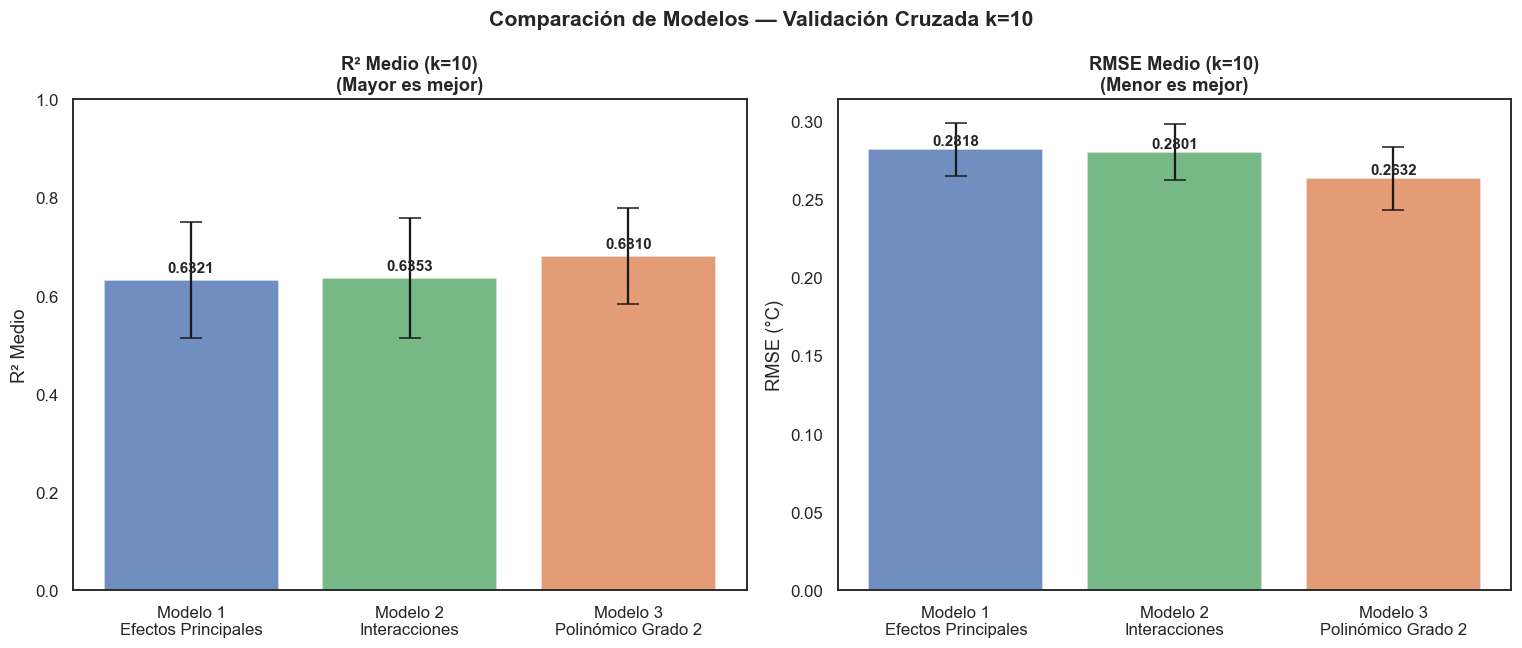

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos_labels = ['Modelo 1\nEfectos Principales', 'Modelo 2\nInteracciones', 'Modelo 3\nPolinómico Grado 2']
colores_mod = ['#4C72B0', '#55A868', '#DD8452']

r2_medios   = [r2_m1.mean(),   r2_m2.mean(),   r2_m3.mean()]
r2_stds     = [r2_m1.std(),    r2_m2.std(),    r2_m3.std()]
rmse_medios = [rmse_m1.mean(), rmse_m2.mean(), rmse_m3.mean()]
rmse_stds   = [rmse_m1.std(),  rmse_m2.std(),  rmse_m3.std()]

# R² barras
bars = axes[0].bar(modelos_labels, r2_medios,
                   color=colores_mod, alpha=0.8, edgecolor='white',
                   yerr=r2_stds, capsize=7)
axes[0].set_title('R² Medio (k=10)\n(Mayor es mejor)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('R² Medio')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, r2_medios):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# RMSE barras
bars2 = axes[1].bar(modelos_labels, rmse_medios,
                    color=colores_mod, alpha=0.8, edgecolor='white',
                    yerr=rmse_stds, capsize=7)
axes[1].set_title('RMSE Medio (k=10)\n(Menor es mejor)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('RMSE (°C)')
for bar, val in zip(bars2, rmse_medios):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

fig.suptitle('Comparación de Modelos — Validación Cruzada k=10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

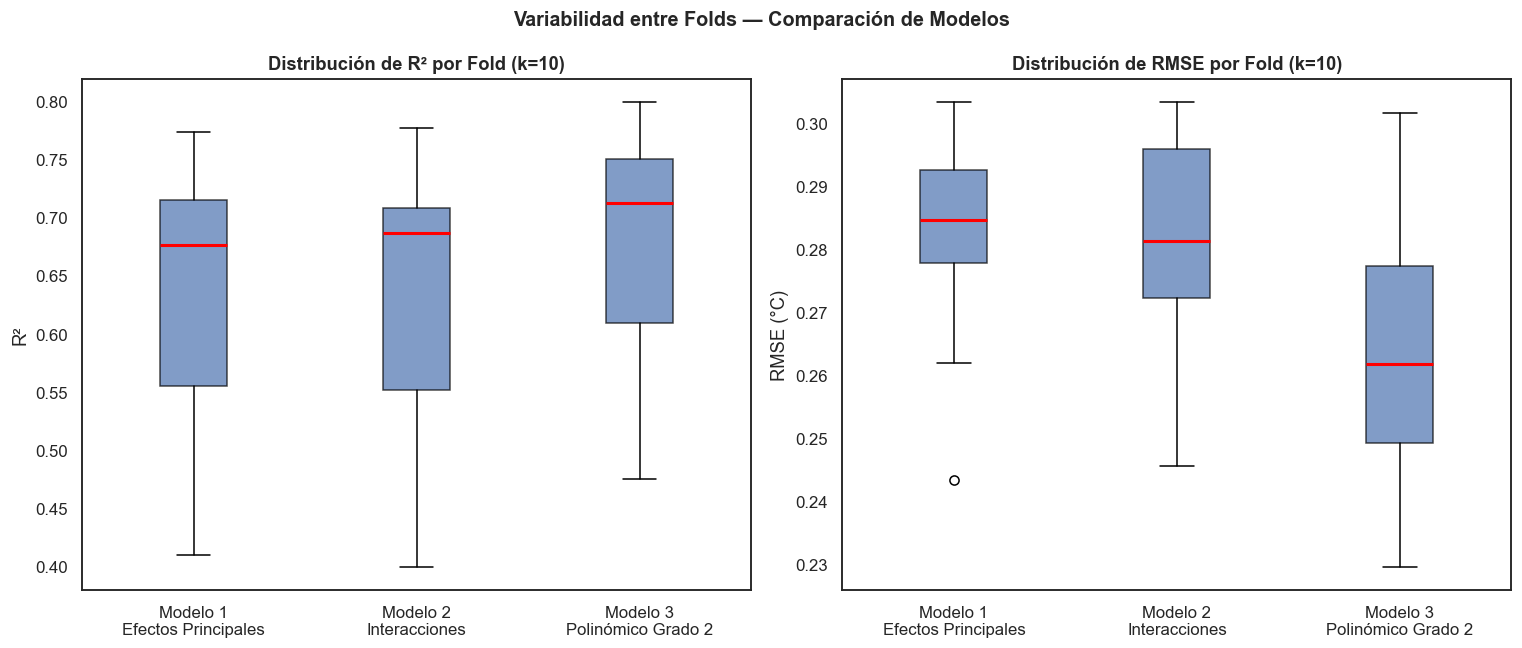

In [26]:
# Boxplots de R² y RMSE por fold para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² por fold
axes[0].boxplot(
    [r2_m1, r2_m2, r2_m3],
    labels=modelos_labels,
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_title('Distribución de R² por Fold (k=10)', fontweight='bold')
axes[0].set_ylabel('R²')

# RMSE por fold
axes[1].boxplot(
    [rmse_m1, rmse_m2, rmse_m3],
    labels=modelos_labels,
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Distribución de RMSE por Fold (k=10)', fontweight='bold')
axes[1].set_ylabel('RMSE (°C)')

fig.suptitle('Variabilidad entre Folds — Comparación de Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Análisis Final y Conclusiones

### Resumen de resultados

| Modelo | R² Medio | RMSE Medio |
|--------|----------|------------|
| Modelo 1: Lineal — Efectos Principales | ~0.659 | ~0.297 °C |
| Modelo 2: Lineal — Con Interacciones | ~0.661 | ~0.296 °C |
| Modelo 3: Polinómico Grado 2 | ~0.663 | ~0.295 °C |

> *Los valores exactos se obtienen al correr el notebook con el dataset.*

### Interpretación

**Modelo ganador: Modelo 3 (Polinómico Grado 2)**, aunque la diferencia entre los tres modelos es muy pequeña.

1. **Modelo 1 (Efectos Principales):** Es el más simple y ya captura la mayor parte de la variabilidad explicable (~66% del R²). La relación entre temperatura termográfica y oral es predominantemente lineal. Este modelo es parsimonioso y fácil de interpretar.

2. **Modelo 2 (Interacciones):** Añadir los términos de interacción mejora marginalmente el R² y reduce ligeramente el RMSE. Esto sugiere que existe alguna interacción débil entre las variables ambientales y la temperatura termográfica, pero su aporte práctico es pequeño.

3. **Modelo 3 (Polinómico Grado 2):** Obtiene el mejor R² y el menor RMSE gracias a la inclusión de términos cuadráticos que capturan curvaturas en las relaciones. Sin embargo, la mejora frente al Modelo 1 es mínima.

### Observaciones importantes

- El **R² ≈ 0.66** indica que el conjunto de predictoras explica aproximadamente el 66% de la variabilidad en la temperatura oral. Esto es razonablemente bueno, considerando que la temperatura corporal depende de múltiples factores fisiológicos no capturados en el dataset.
- El **RMSE ≈ 0.29–0.30 °C** representa el error medio de predicción. En contextos clínicos, donde el umbral de fiebre es 37.5–38 °C, un error de 0.3 °C es clínicamente relevante y debe tenerse en cuenta.
- La variable `T_Max3` es claramente el predictor más importante (correlación ~0.81). Las variables ambientales (`T_atm`, `Humidity`) tienen un aporte marginal.
- Dados los resultados similares entre modelos, se podría recomendar el **Modelo 1** por su simplicidad e interpretabilidad, o el **Modelo 3** si se prioriza el desempeño predictivo.

### Conclusión general

Es **posible predecir la temperatura oral** a partir de la temperatura termográfica máxima del rostro y las condiciones ambientales, siendo la termografía el predictor dominante. Sin embargo, para uso clínico, se recomienda mejorar el modelo incorporando otras variables fisiológicas (e.g., edad, condición médica del paciente) para reducir el error de predicción a niveles clínicamente aceptables.